In [98]:
# Suppress warnings and unnecessary output
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Load and preprocess data
df = pd.read_csv(r"c:\Users\dasam\OneDrive\Documents\Desktop\Infosys\AgriYield_Project\Version1\required\crop_date_yield.csv", parse_dates=["Date"])
df['Date'] = pd.to_datetime(df['Date'])
df.set_index("Date", inplace=True)
df = df.select_dtypes(include="number")
df = df.groupby(df.index).mean()
df = df.asfreq("D")
df = df.interpolate(method="time")

# ARIMA Prediction
model_arima = ARIMA(df["Crop_Yield"], order=(2,1,2))
arima_forecast = model_arima.fit().forecast(10)

# SARIMAX Prediction
target = df["Crop_Yield"]
exog = df.drop(columns=["Crop_Yield"])
model_sarimax = SARIMAX(target, order=(1,1,1), exog=exog, seasonal_order=(0,0,0,0))
sarimax_forecast = model_sarimax.fit(disp=False).get_forecast(steps=10, exog=exog.iloc[-10:]).predicted_mean

# Create combined forecast DataFrame
forecast_df = pd.DataFrame({
    'Date': pd.date_range(start=df.index[-1], periods=11, freq='D')[1:],
    'ARIMA_Forecast': arima_forecast.values,
    'SARIMAX_Forecast': sarimax_forecast.values,
    'Average_Forecast': (arima_forecast.values + sarimax_forecast.values) / 2
})
forecast_df.set_index('Date', inplace=True)

print("\nCrop Yield Forecasts for Next 10 Days")
print("=" * 50)
print("\nPredicted Yield (tons/hectare):")
print("-" * 50)
print(forecast_df.round(2))


Crop Yield Forecasts for Next 10 Days

Predicted Yield (tons/hectare):
--------------------------------------------------
            ARIMA_Forecast  SARIMAX_Forecast  Average_Forecast
Date                                                          
2025-09-30           39.49             43.66             41.57
2025-10-01           40.76             44.46             42.61
2025-10-02           39.54             36.85             38.20
2025-10-03           40.45             32.95             36.70
2025-10-04           39.78             29.18             34.48
2025-10-05           40.27             44.00             42.13
2025-10-06           39.91             48.26             44.08
2025-10-07           40.18             36.08             38.13
2025-10-08           39.98             46.20             43.09
2025-10-09           40.12             30.45             35.29


In [99]:
# Import required libraries
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [100]:
df = pd.read_csv(r"c:\Users\dasam\OneDrive\Documents\Desktop\Infosys\AgriYield_Project\Version1\required\crop_date_yield.csv", parse_dates=["Date"])
df['Date'] = pd.to_datetime(df['Date'])
df.set_index("Date", inplace=True)
df = df.select_dtypes(include="number")
df = df.groupby(df.index).mean()
df = df.asfreq("D")
df = df.interpolate(method="time")

In [101]:
# Prepare data for analysis
series = df["Crop_Yield"]

# ADF Test for Stationarity
def adf_test(series):
    result = adfuller(series.dropna())
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value}')
    if result[1] <= 0.05:
        print("Result: Series is stationary")
    else:
        print("Result: Series is non-stationary")

print("=== ADF Test for Stationarity ===")
adf_test(series)

=== ADF Test for Stationarity ===
ADF Statistic: -7.070123842001316
p-value: 4.962137514920128e-10
Critical Values:
	1%: -3.431877719716477
	5%: -2.862215062045795
	10%: -2.567129340613753
Result: Series is stationary


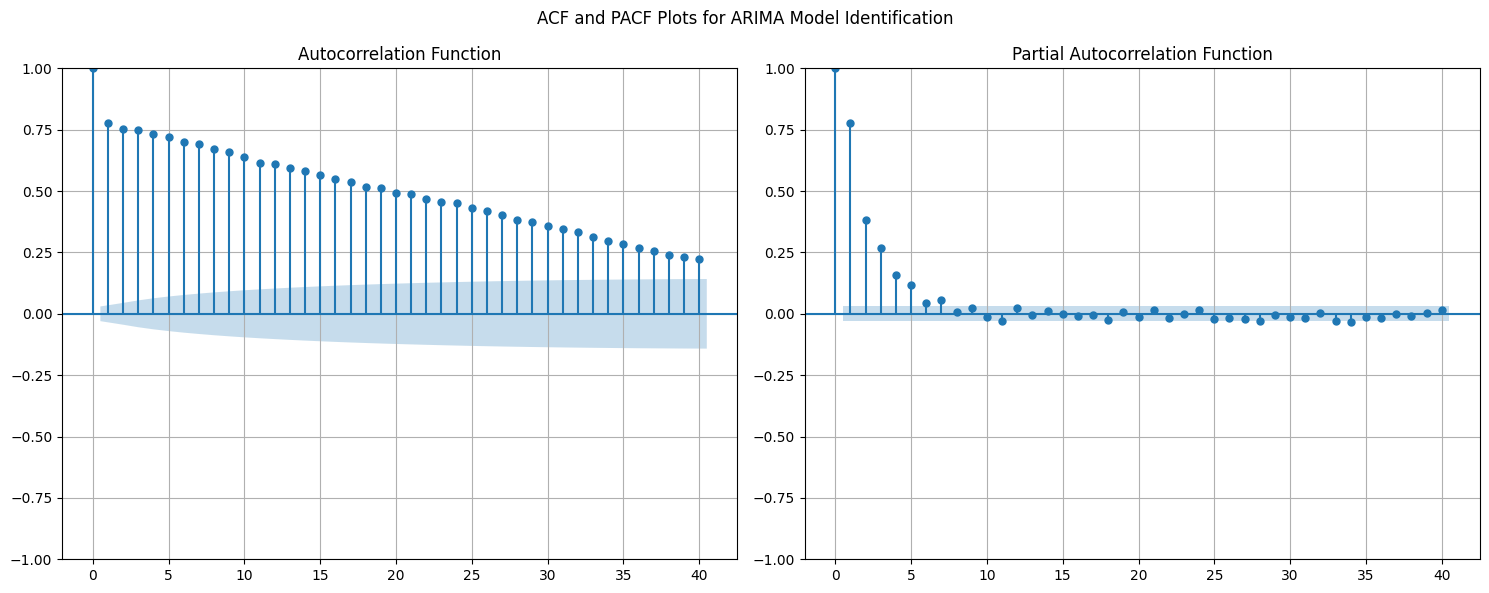

In [102]:
# ACF and PACF Analysis for ARIMA model identification
plt.figure(figsize=(15,6))
plt.subplot(121)
plot_acf(series.dropna(), lags=40, ax=plt.gca(), title='Autocorrelation Function')
plt.grid(True)
plt.subplot(122)
plot_pacf(series.dropna(), lags=40, ax=plt.gca(), method="ywm", title='Partial Autocorrelation Function')
plt.grid(True)
plt.suptitle("ACF and PACF Plots for ARIMA Model Identification")
plt.tight_layout()
plt.show()

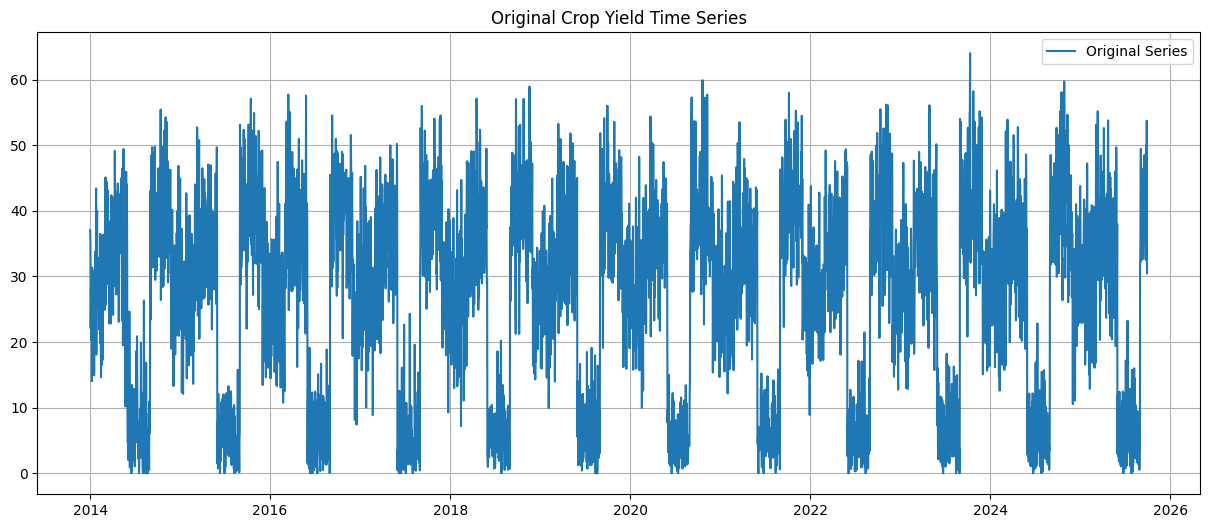

In [103]:
plt.figure(figsize=(15,6))
plt.plot(series.index, series.values, label='Original Series')
plt.title('Original Crop Yield Time Series')
plt.grid(True)
plt.legend()
plt.show()

=== Univariate ARIMA Model (2,1,2) ===
AIC: 30128.46
BIC: 30160.28
Log Likelihood: -15059.23

ARIMA Forecast (next 10 days):
2025-09-30    39.49
2025-10-01    40.76
2025-10-02    39.54
2025-10-03    40.45
2025-10-04    39.78
2025-10-05    40.27
2025-10-06    39.91
2025-10-07    40.18
2025-10-08    39.98
2025-10-09    40.12
Freq: D, Name: predicted_mean, dtype: float64
AIC: 30128.46
BIC: 30160.28
Log Likelihood: -15059.23

ARIMA Forecast (next 10 days):
2025-09-30    39.49
2025-10-01    40.76
2025-10-02    39.54
2025-10-03    40.45
2025-10-04    39.78
2025-10-05    40.27
2025-10-06    39.91
2025-10-07    40.18
2025-10-08    39.98
2025-10-09    40.12
Freq: D, Name: predicted_mean, dtype: float64


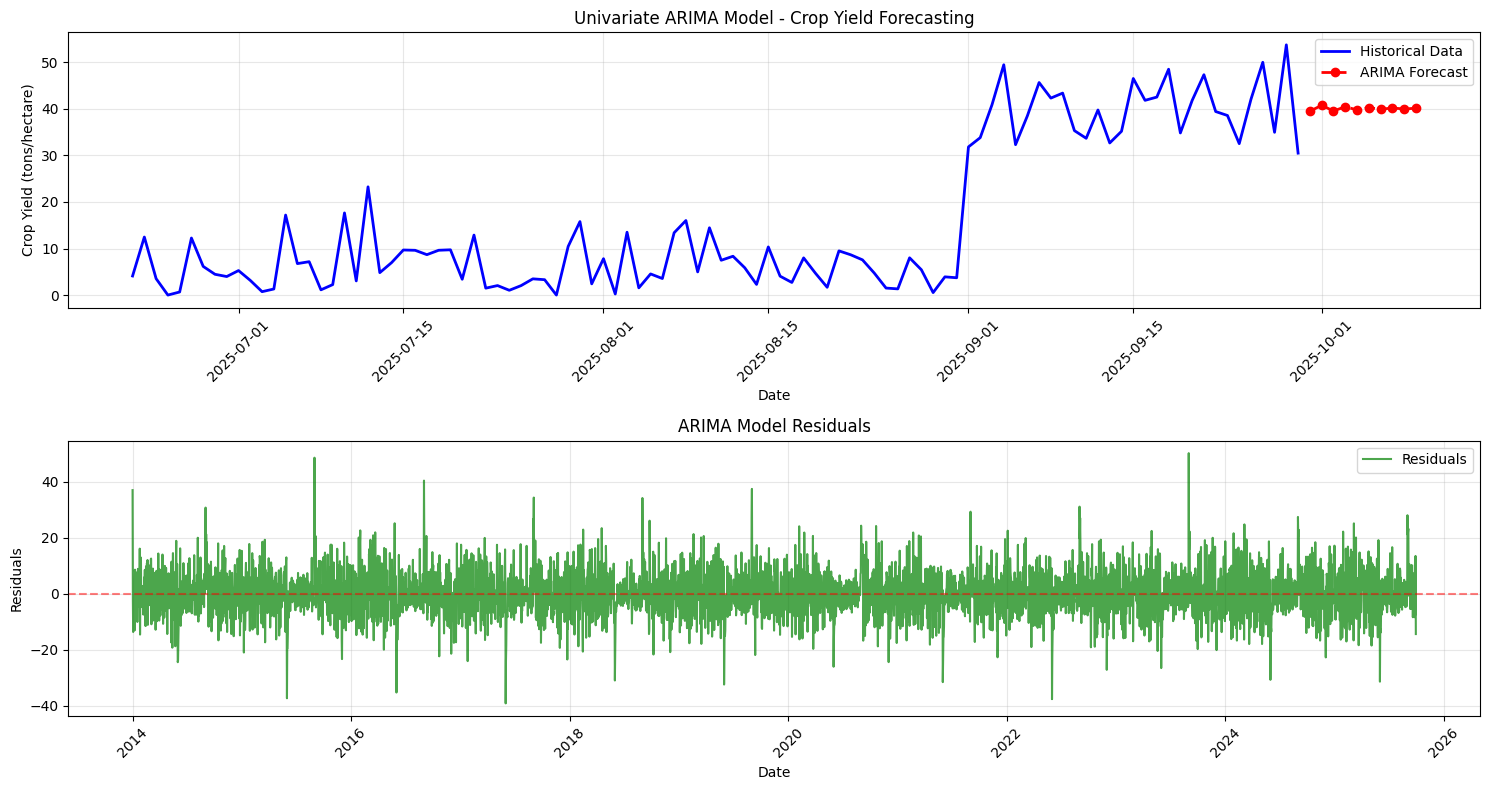

In [104]:
# Univariate ARIMA Model for Time Series Forecasting
print("=== Univariate ARIMA Model (2,1,2) ===")
model_arima = ARIMA(df["Crop_Yield"], order=(2,1,2))
arima_fit = model_arima.fit()
arima_forecast = arima_fit.forecast(10)

print(f"AIC: {arima_fit.aic:.2f}")
print(f"BIC: {arima_fit.bic:.2f}")
print(f"Log Likelihood: {arima_fit.llf:.2f}")
print("\nARIMA Forecast (next 10 days):")
print(arima_forecast.round(2))

# Plot ARIMA Results
plt.figure(figsize=(15, 8))

# Plot historical data and forecast
plt.subplot(2,1,1)
plt.plot(series.index[-100:], series.values[-100:], label='Historical Data', color='blue', linewidth=2)
forecast_dates = pd.date_range(start=df.index[-1], periods=11, freq='D')[1:]
plt.plot(forecast_dates, arima_forecast, '--', label='ARIMA Forecast', color='red', linewidth=2, marker='o')
plt.title('Univariate ARIMA Model - Crop Yield Forecasting')
plt.xlabel('Date')
plt.ylabel('Crop Yield (tons/hectare)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=45)

# Plot residuals
plt.subplot(2,1,2)
residuals = arima_fit.resid
plt.plot(residuals.index, residuals, label='Residuals', color='green', alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.title('ARIMA Model Residuals')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

=== Multivariate ARIMA Model (SARIMAX) ===
AIC: 25140.01
BIC: 25210.01
Log Likelihood: -12559.00
Number of exogenous variables: 8
Exogenous variables: ['Soil_pH', 'Temperature', 'Humidity', 'Wind_Speed', 'N', 'P', 'K', 'Soil_Quality']

SARIMAX Forecast (next 10 days):
2025-09-30    43.66
2025-10-01    44.46
2025-10-02    36.85
2025-10-03    32.95
2025-10-04    29.18
2025-10-05    44.00
2025-10-06    48.26
2025-10-07    36.08
2025-10-08    46.20
2025-10-09    30.45
Freq: D, Name: predicted_mean, dtype: float64
AIC: 25140.01
BIC: 25210.01
Log Likelihood: -12559.00
Number of exogenous variables: 8
Exogenous variables: ['Soil_pH', 'Temperature', 'Humidity', 'Wind_Speed', 'N', 'P', 'K', 'Soil_Quality']

SARIMAX Forecast (next 10 days):
2025-09-30    43.66
2025-10-01    44.46
2025-10-02    36.85
2025-10-03    32.95
2025-10-04    29.18
2025-10-05    44.00
2025-10-06    48.26
2025-10-07    36.08
2025-10-08    46.20
2025-10-09    30.45
Freq: D, Name: predicted_mean, dtype: float64


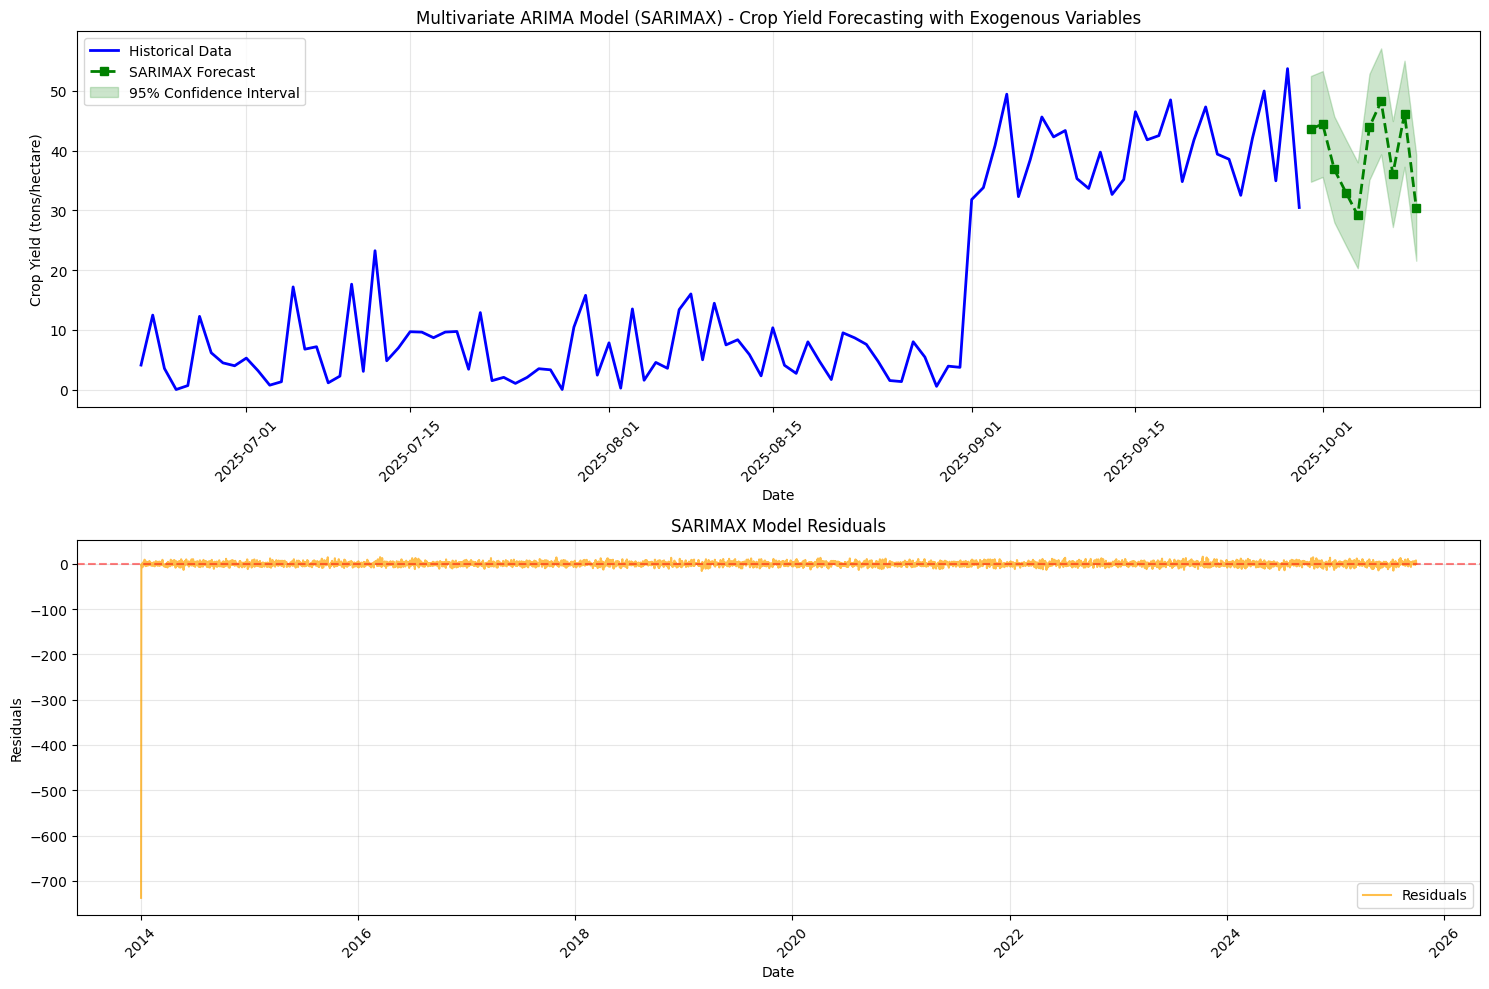

In [105]:
# Multivariate ARIMA Model (SARIMAX) for Time Series Forecasting
print("=== Multivariate ARIMA Model (SARIMAX) ===")
target = df["Crop_Yield"]
exog = df.drop(columns=["Crop_Yield"])

model_sarimax = SARIMAX(target, order=(1,1,1), exog=exog, seasonal_order=(0,0,0,0))
sarimax_fit = model_sarimax.fit(disp=False)
sarimax_forecast = sarimax_fit.get_forecast(steps=10, exog=exog.iloc[-10:])
sarimax_pred = sarimax_forecast.predicted_mean
sarimax_conf_int = sarimax_forecast.conf_int()

print(f"AIC: {sarimax_fit.aic:.2f}")
print(f"BIC: {sarimax_fit.bic:.2f}")
print(f"Log Likelihood: {sarimax_fit.llf:.2f}")
print(f"Number of exogenous variables: {exog.shape[1]}")
print(f"Exogenous variables: {list(exog.columns)}")
print("\nSARIMAX Forecast (next 10 days):")
print(sarimax_pred.round(2))

# Plot SARIMAX Results
plt.figure(figsize=(15, 10))

# Plot historical data and forecast with confidence intervals
plt.subplot(2,1,1)
plt.plot(target.index[-100:], target.values[-100:], label='Historical Data', color='blue', linewidth=2)
forecast_dates = pd.date_range(start=df.index[-1], periods=11, freq='D')[1:]
plt.plot(forecast_dates, sarimax_pred, '--', label='SARIMAX Forecast', color='green', linewidth=2, marker='s')
plt.fill_between(forecast_dates, 
                 sarimax_conf_int.iloc[:,0], 
                 sarimax_conf_int.iloc[:,1], 
                 color='green', alpha=0.2, label='95% Confidence Interval')
plt.title('Multivariate ARIMA Model (SARIMAX) - Crop Yield Forecasting with Exogenous Variables')
plt.xlabel('Date')
plt.ylabel('Crop Yield (tons/hectare)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=45)

# Plot residuals
plt.subplot(2,1,2)
residuals = sarimax_fit.resid
plt.plot(residuals.index, residuals, label='Residuals', color='orange', alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.title('SARIMAX Model Residuals')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()